<a href="https://colab.research.google.com/github/rjlobosco/unifesp/blob/main/Aula_7_Introducao_Ponto_Fixo_Babilonico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula introdutória: iteração de ponto fixo e método babilônico



## 1. Ideia de aproximações sucessivas

Muitos problemas de engenharia não são resolvidos diretamente por uma fórmula simples. Uma alternativa é começar com uma estimativa e aplicar repetidamente uma regra de melhoria.

Se uma função `g` possui um ponto fixo `x*`, então:

$$g(x^*)=x^*.$$

A iteração de ponto fixo é definida por:

$$x_{k+1}=g(x_k).$$

O objetivo é produzir uma sequência que se aproxime de `x*`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def iterar_ponto_fixo(g, x0, tol=1e-8, max_iter=50):
    historico = [float(x0)]
    x = float(x0)
    for k in range(max_iter):
        x_novo = float(g(x))
        historico.append(x_novo)
        if abs(x_novo - x) < tol:
            break
        x = x_novo
    return historico

## 2. Exemplo introdutório: um ponto fixo simples

Considere:

$$g(x)=\frac{x+2}{3}.$$

O ponto fixo satisfaz:

$$x=\frac{x+2}{3} \quad\Rightarrow\quad 3x=x+2 \quad\Rightarrow\quad x=1.$$

Agora vamos descobrir esse valor apenas por iteração.

In [14]:
g1 = lambda x: (x+2)/3
hist1 = iterar_ponto_fixo(g1, x0=10, tol=1e-10)
for k, xk in enumerate(hist1):
    print(f'k={k:2d}  x_k={xk:.12f}  erro em relação a 1={abs(xk-1):.3e}')

k= 0  x_k=10.000000000000  erro em relação a 1=9.000e+00
k= 1  x_k=4.000000000000  erro em relação a 1=3.000e+00
k= 2  x_k=2.000000000000  erro em relação a 1=1.000e+00
k= 3  x_k=1.333333333333  erro em relação a 1=3.333e-01
k= 4  x_k=1.111111111111  erro em relação a 1=1.111e-01
k= 5  x_k=1.037037037037  erro em relação a 1=3.704e-02
k= 6  x_k=1.012345679012  erro em relação a 1=1.235e-02
k= 7  x_k=1.004115226337  erro em relação a 1=4.115e-03
k= 8  x_k=1.001371742112  erro em relação a 1=1.372e-03
k= 9  x_k=1.000457247371  erro em relação a 1=4.572e-04
k=10  x_k=1.000152415790  erro em relação a 1=1.524e-04
k=11  x_k=1.000050805263  erro em relação a 1=5.081e-05
k=12  x_k=1.000016935088  erro em relação a 1=1.694e-05
k=13  x_k=1.000005645029  erro em relação a 1=5.645e-06
k=14  x_k=1.000001881676  erro em relação a 1=1.882e-06
k=15  x_k=1.000000627225  erro em relação a 1=6.272e-07
k=16  x_k=1.000000209075  erro em relação a 1=2.091e-07
k=17  x_k=1.000000069692  erro em relação a 1=6

### Observação: por que algumas iterações convergem?

Na iteração de ponto fixo, calculamos repetidamente:

$$
x_{k+1}=g(x_k)
$$

Suponha que `x*` seja o ponto fixo da função, isto é:

$$
g(x^*)=x^*
$$

O erro da aproximação na iteração `k` é definido por:

$$
e_k=x_k-x^*
$$

Pelo teorema do valor médio, existe um ponto `c` entre `x_k` e `x*` tal que:

$$
g(x_k)-g(x^*)=g'(c)(x_k-x^*)
$$

Como `g(x*) = x*`, podemos escrever:

$$
e_{k+1}=g(x_k)-g(x^*)=g'(c)e_k
$$

Assim:

$$
|e_{k+1}|=|g'(c)|\,|e_k|
$$

Essa relação mostra que a derivada de `g` controla a evolução do erro.

- Se `|g'(x)| < 1`, o erro tende a diminuir.
- Se `|g'(x)|` for muito menor que `1`, a convergência tende a ser rápida.
- Se `|g'(x)|` estiver próximo de `1`, a convergência será lenta.
- Se `|g'(x)| > 1`, o erro pode aumentar e a iteração pode divergir.
- Se `g'(x)` for negativo, a sequência pode oscilar em torno do ponto fixo.

No exemplo:

$$
g(x)=\frac{x+2}{3}
$$

temos:

$$
g'(x)=\frac{1}{3}
$$

Como:

$$
|g'(x)|=\frac{1}{3}<1
$$

cada erro é aproximadamente reduzido a um terço do erro anterior. Por isso, a sequência converge para o ponto fixo:

$$
x^*=1
$$

Por outro lado, para:

$$
g(x)=2x
$$

temos:

$$
g'(x)=2
$$

Nesse caso:

$$
|g'(x)|=2>1
$$

e cada erro tende a ser multiplicado por dois. A sequência se afasta do ponto fixo, caracterizando divergência.

É importante observar que a condição:

$$
|g'(x)|<1
$$

é uma condição suficiente local ou regional. Ela não garante a convergência para qualquer estimativa inicial. O valor inicial deve estar em uma região onde a função iterativa seja adequada e permaneça bem definida.

## 3. Construção do método babilônico

Queremos calcular a raiz quadrada de um número positivo `S`. Para isso, procuramos um número `x` que satisfaça:

$$
x^2=S
$$

Por exemplo, para calcular `sqrt(10)`, queremos encontrar um valor `x` tal que:

$$
x^2=10
$$

Sabemos que a raiz está entre `3` e `4`, pois:

$$
3^2=9
\qquad\text{e}\qquad
4^2=16
$$

Podemos começar com uma estimativa inicial. Considere:

$$
x_0=3
$$

Como `3` é menor que `sqrt(10)`, podemos obter uma segunda estimativa dividindo `S` pela aproximação atual:

$$
\frac{S}{x_0}=\frac{10}{3}\approx 3{,}3333
$$

As duas estimativas são:

- `x_0 = 3`, que está abaixo da raiz;
- `S/x_0 = 3,3333`, que está acima da raiz.

Uma forma natural de obter uma aproximação intermediária é calcular a média aritmética desses dois valores:

$$
x_1=
\frac{1}{2}
\left(
x_0+\frac{S}{x_0}
\right)
$$

Para `S=10` e `x_0=3`, temos:

$$
x_1=
\frac{1}{2}
\left(
3+\frac{10}{3}
\right)
=
3{,}1666667
$$

Agora repetimos o mesmo procedimento usando `x_1`:

$$
x_2=
\frac{1}{2}
\left(
x_1+\frac{S}{x_1}
\right)
$$

Substituindo os valores:

$$
x_2=
\frac{1}{2}
\left(
3{,}1666667+
\frac{10}{3{,}1666667}
\right)
\approx 3{,}1622807
$$

A nova aproximação já está muito próxima de:

$$
\sqrt{10}\approx 3{,}16227766
$$

Portanto, o procedimento geral é:

1. escolher uma estimativa positiva `x_0`;
2. calcular `S/x_0`;
3. fazer a média entre `x_0` e `S/x_0`;
4. usar essa média como a próxima aproximação;
5. repetir até atingir a precisão desejada.

A fórmula iterativa do método babilônico é:

$$
\boxed{
x_{k+1}
=
\frac{1}{2}
\left(
x_k+\frac{S}{x_k}
\right)
}
$$

Essa fórmula define a função iterativa:

$$
g(x)=
\frac{1}{2}
\left(
x+\frac{S}{x}
\right)
$$

Assim, o método pode ser escrito como uma iteração de ponto fixo:

$$
x_{k+1}=g(x_k)
$$

No ponto de convergência, a aproximação não muda mais significativamente. Se `x*` representa a raiz quadrada de `S`, então:

$$
x^*=g(x^*)
$$

Substituindo a função `g`:

$$
x^*=
\frac{1}{2}
\left(
x^*+\frac{S}{x^*}
\right)
$$

Multiplicando por `2`:

$$
2x^*=x^*+\frac{S}{x^*}
$$

Logo:

$$
x^*=\frac{S}{x^*}
$$

Multiplicando por `x*`, obtemos:

$$
(x^*)^2=S
$$

Portanto:

$$
x^*=\sqrt{S}
$$

O método babilônico funciona porque combina duas estimativas que ficam em lados opostos da raiz e substitui essas estimativas por uma média. A cada iteração, o valor obtido tende a se aproximar da raiz quadrada procurada.

## 4. Primeiro cálculo manual: `sqrt(2)`

Começando com `x_0 = 1`:

$$x_1=\frac{1}{2}\left(1+\frac{2}{1}\right)=1{,}5,$$

$$x_2=\frac{1}{2}\left(1{,}5+\frac{2}{1{,}5}\right)=1{,}4166667,$$

$$x_3=\frac{1}{2}\left(1{,}4166667+\frac{2}{1{,}4166667}\right)\approx1{,}4142157.$$

A sequência se aproxima de `1,41421356...`.

In [3]:
def babilonico(S, x0, tol=1e-10, max_iter=100):
    if S < 0 or x0 <= 0:
        raise ValueError('Use S >= 0 e x0 > 0.')
    if S == 0:
        return [0.0]
    x = float(x0)
    tabela = []
    for k in range(max_iter):
        x_novo = 0.5*(x + S/x)
        erro_iter = abs(x_novo-x)
        erro_exato = abs(x_novo-np.sqrt(S))
        residuo = abs(x_novo**2-S)
        tabela.append([k+1, x_novo, erro_iter, erro_exato, residuo])
        if erro_iter < tol:
            break
        x = x_novo
    return tabela

tab = babilonico(2, 1, tol=1e-12)
df = pd.DataFrame(tab, columns=['k','x_k','erro_iteracao','erro_exato','residuo'])
display(df)

,k,x_k,erro_iteracao,erro_exato,residuo
0,1,1.500000,5.000000e-01,8.578644e-02,2.500000e-01
1,2,1.416667,8.333333e-02,2.453104e-03,6.944444e-03
2,3,1.414216,2.450980e-03,2.123901e-06,6.007305e-06
3,4,1.414214,2.123900e-06,1.594724e-12,4.510614e-12
4,5,1.414214,1.594946e-12,2.220446e-16,4.440892e-16
5,6,1.414214,0.000000e+00,2.220446e-16,4.440892e-16


## 5. Exercício guiado 1: `sqrt(5)`

Antes de executar o código, estime mentalmente entre quais dois inteiros está `sqrt(5)`. Depois, use `x_0=2` e registre as quatro primeiras iterações. Compare cada aproximação com o valor de referência do NumPy.

In [4]:
tab5 = babilonico(5, 2, tol=1e-14)
df5 = pd.DataFrame(tab5, columns=['k','x_k','erro_iteracao','erro_exato','residuo'])
display(df5.head(4))
print('Referência:', np.sqrt(5))

,k,x_k,erro_iteracao,erro_exato,residuo
0,1,2.250000,2.500000e-01,1.393202e-02,6.250000e-02
1,2,2.236111,1.388889e-02,4.313361e-05,1.929012e-04
2,3,2.236068,4.313320e-05,4.160139e-10,1.860471e-09
3,4,2.236068,4.160139e-10,0.000000e+00,8.881784e-16


Referência: 2.23606797749979


## 6. Exercício guiado 2: `sqrt(81)`

Escolha `x_0=10`. Como `81` é um quadrado perfeito, o método deve aproximar-se de `9`. Verifique se a sequência chega exatamente a `9` na aritmética de ponto flutuante.

In [5]:
tab81 = babilonico(81, 10, tol=1e-15)
display(pd.DataFrame(tab81, columns=['k','x_k','erro_iteracao','erro_exato','residuo']))

,k,x_k,erro_iteracao,erro_exato,residuo
0,1,9.050000,9.500000e-01,5.000000e-02,9.025000e-01
1,2,9.000138,4.986188e-02,1.381215e-04,2.486207e-03
2,3,9.000000,1.381205e-04,1.059849e-09,1.907728e-08
3,4,9.000000,1.059849e-09,0.000000e+00,0.000000e+00
4,5,9.000000,0.000000e+00,0.000000e+00,0.000000e+00


## 7. Critérios de parada e epsilon

Um método iterativo gera uma sequência de aproximações:

$$
x_0,\ x_1,\ x_2,\ \ldots,\ x_k
$$

Em teoria, poderíamos continuar calculando novas aproximações indefinidamente. Na prática, precisamos definir quando o resultado já é suficientemente preciso. Essa decisão é feita por meio de um **critério de parada**.

A precisão desejada é definida por uma tolerância, normalmente representada por:

$$
\varepsilon
$$

Quanto menor for o valor de `epsilon`, maior será a precisão exigida. Entretanto, uma tolerância muito pequena pode aumentar o número de iterações e fazer com que o algoritmo atinja os limites da aritmética computacional.

### 7.1 Critério baseado na diferença entre iterações

Um critério simples consiste em comparar duas aproximações consecutivas:

$$
|x_{k+1}-x_k|<\varepsilon
$$

Esse valor mede quanto a sequência mudou entre duas iterações.

Se a diferença for pequena, significa que o método está produzindo valores muito próximos. Dizemos que a sequência está estabilizada.

Por exemplo, se:

$$
x_k=3{,}1622776601
$$

e

$$
x_{k+1}=3{,}1622776602,
$$

então:

$$
|x_{k+1}-x_k|=10^{-10}
$$

Se a tolerância escolhida for:

$$
\varepsilon=10^{-8},
$$

o critério será satisfeito, pois:

$$
10^{-10}<10^{-8}
$$

Esse critério é útil porque não exige conhecer o valor exato da solução.

### 7.2 Critério baseado no resíduo

No método babilônico, queremos resolver:

$$
x^2-S=0
$$

Depois de calcular uma aproximação `x_k`, podemos verificar quanto ela satisfaz a equação:

$$
r_k=x_k^2-S
$$

O módulo desse valor é chamado de resíduo:

$$
|r_k|=|x_k^2-S|
$$

O critério de parada baseado no resíduo é:

$$
|x_k^2-S|<\varepsilon
$$

Esse critério verifica diretamente se a aproximação produz o valor desejado quando substituída na equação original.

Por exemplo, para calcular:

$$
\sqrt{10},
$$

se uma aproximação produzir:

$$
x_k^2=10{,}000000001,
$$

então o resíduo será:

$$
|x_k^2-10|=10^{-9}
$$

Com uma tolerância de:

$$
\varepsilon=10^{-8},
$$

o critério será satisfeito.

### 7.3 Diferença entre os dois critérios

Os critérios medem coisas diferentes:

- `|x_(k+1) - x_k|` mede a mudança entre duas aproximações;
- `|x_k² - S|` mede diretamente o erro na equação que desejamos resolver.

Uma sequência pode mudar muito pouco e ainda apresentar um resíduo relativamente grande. Por isso, em aplicações importantes, é recomendável acompanhar os dois critérios.

Podemos usar a condição:

$$
|x_{k+1}-x_k|<\varepsilon
\quad\text{e}\quad
|x_{k+1}^2-S|<\varepsilon
$$

ou interromper o método quando pelo menos um dos critérios for suficientemente pequeno, dependendo do objetivo da aplicação.

### 7.4 Critério de erro relativo

Quando os valores possuem escalas muito diferentes, o erro absoluto pode não ser suficiente. Nesse caso, podemos usar uma medida relativa:

$$
\frac{|x_{k+1}-x_k|}{1+|x_{k+1}|}<\varepsilon
$$

O termo `1` evita divisão por zero quando a solução é próxima de zero.

Esse critério permite comparar a mudança da aproximação com o tamanho do próprio valor calculado.

### 7.5 Número máximo de iterações

Além da tolerância, devemos definir um número máximo de iterações:

$$
k\leq k_{\max}
$$

Isso evita que o programa fique executando indefinidamente caso:

- a função iterativa não seja convergente;
- a estimativa inicial seja inadequada;
- a tolerância seja muito rigorosa;
- ocorram problemas numéricos;
- a sequência oscile ou diverja.

Um algoritmo confiável deve parar quando a tolerância for atingida ou quando o número máximo de iterações for alcançado.

### 7.6 Epsilonpsilon da máquina

O epsilon da máquina é diferente da tolerância escolhida para o método.

Ele representa a menor diferença que o computador consegue distinguir aproximadamente entre `1` e um número imediatamente maior que `1`, utilizando determinado tipo numérico.

Para números do tipo `float64`, podemos consultar:

```python
import numpy as np

epsilon_maquina = np.finfo(float).eps
print(epsilon_maquina)

In [6]:
print('epsilon da máquina para float64:', np.finfo(float).eps)
for tol in [1e-3, 1e-6, 1e-10, 1e-14]:
    t = babilonico(10, 3, tol=tol)
    r = t[-1][1]
    print(f'tol={tol:.0e} | iterações={len(t):2d} | raiz={r:.14f} | resíduo={abs(r*r-10):.3e}')

epsilon da máquina para float64: 2.220446049250313e-16
tol=1e-03 | iterações= 3 | raiz=3.16227766016984 | resíduo=9.249e-12
tol=1e-06 | iterações= 4 | raiz=3.16227766016838 | resíduo=1.776e-15
tol=1e-10 | iterações= 4 | raiz=3.16227766016838 | resíduo=1.776e-15
tol=1e-14 | iterações= 5 | raiz=3.16227766016838 | resíduo=1.776e-15


## 8. Experimento: estimativa inicial

Uma estimativa inicial positiva garante o funcionamento do método para `S>0`, mas uma escolha ruim pode exigir mais iterações. Compare quatro valores iniciais para `sqrt(1000)`.

In [7]:
for x0 in [1, 10, 100, 1000]:
    t = babilonico(1000, x0, tol=1e-10)
    print(f'x0={x0:7.1f} | iterações={len(t):2d} | aproximação={t[-1][1]:.12f}')

x0=    1.0 | iterações=10 | aproximação=31.622776601684
x0=   10.0 | iterações= 7 | aproximação=31.622776601684
x0=  100.0 | iterações= 7 | aproximação=31.622776601684
x0= 1000.0 | iterações=10 | aproximação=31.622776601684


## 9. Aplicação numérica: diagonal de um retângulo

Um retângulo tem lados `3,0 m` e `4,0 m`. Sua diagonal satisfaz:

$$d^2=3^2+4^2=25.$$

Use o método babilônico para calcular `d`. O resultado esperado é próximo de `5 m`.

In [8]:
dtab = babilonico(3**2 + 4**2, 4, tol=1e-12)
d = dtab[-1][1]
print(f'diagonal calculada: {d:.12f} m')
print(f'erro absoluto: {abs(d-5):.3e} m')

diagonal calculada: 5.000000000000 m
erro absoluto: 0.000e+00 m


## 10. Aplicação numérica: norma de um vetor

Para `v=(6,8)`, a norma euclidiana é:

$$\|v\|_2=\sqrt{6^2+8^2}.$$

Calcule a soma dos quadrados e use o método babilônico para obter a norma.

In [9]:
v = np.array([6.0, 8.0])
soma = np.sum(v**2)
norma = babilonico(soma, 8, tol=1e-12)[-1][1]
print('soma dos quadrados:', soma)
print('norma:', norma)

soma dos quadrados: 100.0
norma: 10.0


## 11. Atividade prática final

1. Calcule `sqrt(37)` com `x0=6`.
2. Monte uma tabela contendo `k`, `x_k`, erro entre iterações e resíduo.
3. Repita com tolerâncias `10⁻4`, `10⁻8` e `10⁻12`.
4. Calcule a diagonal de um quadrado de lado `2,75 m`.
5. Calcule a norma do vetor `(1.2, -3.4, 5.6)`.
6. Explique por que o método babilônico é uma iteração de ponto fixo.
7. Compare o critério baseado na mudança entre iterações com o critério baseado no resíduo.

## 10. Como construir uma iteração linear a partir de uma função

Considere o problema de encontrar um zero da função:

$$
f(x)=0
$$

Um zero de `f` é um valor `x*` que satisfaz:

$$
f(x^*)=0
$$

A ideia é transformar esse problema em uma equação de ponto fixo, isto é, em uma expressão da forma:

$$
x=g(x)
$$

Uma forma simples de fazer isso é escolher um número real `lambda`, diferente de zero, e escrever:

$$
g(x)=x-\lambda f(x)
$$

A iteração correspondente será:

$$
x_{k+1}=g(x_k)
$$

ou, substituindo a expressão de `g`:

$$
x_{k+1}=x_k-\lambda f(x_k)
$$

### Por que essa transformação funciona?

Se `x*` é uma raiz de `f`, então:

$$
f(x^*)=0
$$

Substituindo `x*` na função iterativa:

$$
g(x^*)=x^*-\lambda f(x^*)
$$

Como `f(x*)=0`, obtemos:

$$
g(x^*)=x^*
$$

Portanto, toda raiz de `f` é um ponto fixo de `g`.

### O papel do parâmetro lambda

O parâmetro `lambda` controla o tamanho da correção aplicada a cada aproximação:

$$
x_{k+1}=x_k-\lambda f(x_k)
$$

- Se `lambda` for pequeno, a correção será pequena e a convergência poderá ser lenta.
- Se `lambda` tiver valor adequado, a sequência poderá convergir rapidamente.
- Se `lambda` for muito grande, a sequência poderá oscilar ou divergir.
- Se o sinal de `lambda` for inadequado, a correção poderá afastar a aproximação da raiz.

Assim, escolher `lambda` é semelhante a escolher o tamanho de um passo em um processo iterativo.

## 10.1 Exemplo com uma função linear

Considere:

$$
f(x)=2x-6
$$

O zero exato é obtido por:

$$
2x-6=0
$$

Logo:

$$
x^*=3
$$

Construindo a função iterativa:

$$
g(x)=x-\lambda(2x-6)
$$

Distribuindo os termos:

$$
g(x)=x-2\lambda x+6\lambda
$$

Portanto:

$$
g(x)=(1-2\lambda)x+6\lambda
$$

A iteração será:

$$
x_{k+1}=(1-2\lambda)x_k+6\lambda
$$

Como a função iterativa é linear, podemos analisar diretamente sua convergência.

O erro da iteração `k` é:

$$
e_k=x_k-x^*
$$

Para essa função, o erro evolui de acordo com:

$$
e_{k+1}=(1-2\lambda)e_k
$$

Para que o erro diminua, precisamos que:

$$
|1-2\lambda|<1
$$

Resolvendo essa desigualdade:

$$
-1<1-2\lambda<1
$$

Subtraindo `1` dos três membros:

$$
-2<-2\lambda<0
$$

Dividindo por `-2` e invertendo os sinais:

$$
0<\lambda<1
$$

Portanto, para essa função, a iteração converge quando:

$$
0<\lambda<1
$$

## 10.2 Comparação entre diferentes valores de lambda

Vamos começar com `x_0=0` e testar diferentes valores de `lambda`.

- Para `lambda=0.2`, o fator de erro é `1-2lambda=0.6`. A sequência converge lentamente.
- Para `lambda=0.5`, o fator de erro é `0`. A raiz é obtida em uma única iteração.
- Para `lambda=0.8`, o fator de erro é `-0.6`. A sequência converge, mas alterna em torno da raiz.
- Para `lambda=1.2`, o fator de erro é `-1.4`. O erro aumenta e a sequência diverge.

```python
def iteracao_linear(a, b, x0, lamb, tolerancia=1e-10, max_iter=30):
    """
    Resolve f(x) = a*x + b usando:
    
        x_(k+1) = x_k - lambda*f(x_k)
    """
    
    x = float(x0)
    historico = [x]
    
    for k in range(max_iter):
        f_valor = a*x + b
        x_novo = x - lamb*f_valor
        
        historico.append(x_novo)
        
        if abs(x_novo - x) < tolerancia:
            break
        
        x = x_novo
    
    return historico


valores_lambda = [0.2, 0.5, 0.8, 1.2]

for lamb in valores_lambda:
    historico = iteracao_linear(
        a=2,
        b=-6,
        x0=0,
        lamb=lamb
    )
    
    print(
        f"lambda = {lamb}: "
        f"iterações = {len(historico)-1}, "
        f"último valor = {historico[-1]:.6f}"
    )

In [10]:
# Iteração linear para f(x)=2x-6, cuja raiz é x*=3
def iteracao_linear(a, b, x0, lamb, tol=1e-10, max_iter=100):
    x = float(x0); hist = [x]
    for _ in range(max_iter):
        x_novo = x - lamb*(a*x+b)
        hist.append(x_novo)
        if abs(x_novo-x) < tol: break
        x = x_novo
    return hist

for lamb in [0.2, 0.5, 1.2]:
    h = iteracao_linear(2, -6, x0=0, lamb=lamb)
    print(f'lambda={lamb}: iterações={len(h)-1}, último valor={h[-1]:.6f}')

lambda=0.2: iterações=47, último valor=3.000000
lambda=0.5: iterações=2, último valor=3.000000
lambda=1.2: iterações=100, último valor=-1230055826654970.000000


## 11. Ilustração de iterações que não convergem

A convergência depende da função `g` e da estimativa inicial. Se `g` amplia os erros, a sequência pode divergir ou oscilar.

Exemplo A:

$$g(x)=2x.$$

O ponto fixo é `0`, mas, para qualquer `x_0` diferente de zero, o módulo dobra a cada iteração.

Exemplo B:

$$g(x)=-x.$$

A sequência alterna entre `x_0` e `-x_0` e não se aproxima do ponto fixo, exceto se `x_0=0`.

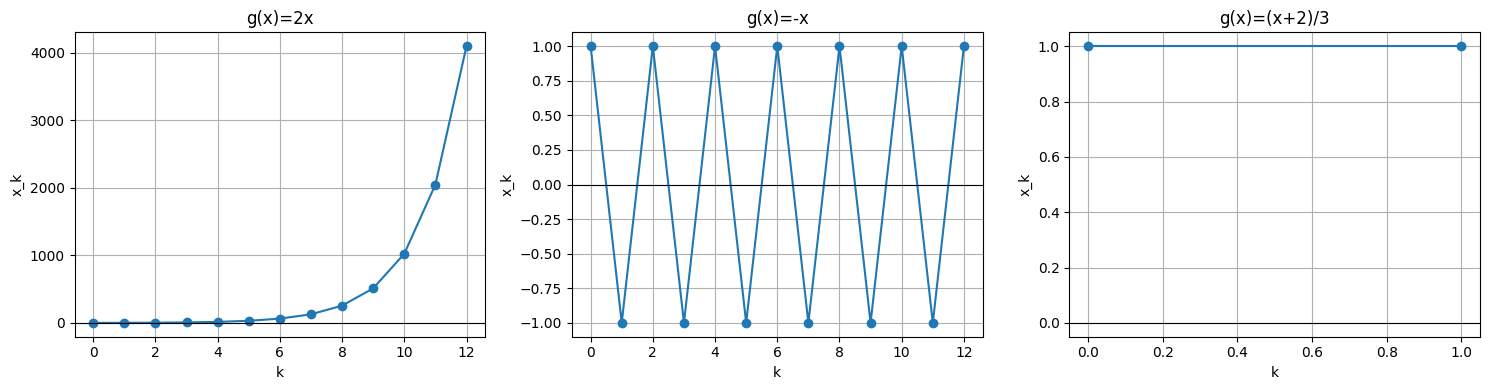

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
casos = [(lambda x: 2*x, 'g(x)=2x'), (lambda x: -x, 'g(x)=-x'), (lambda x: (x+2)/3, 'g(x)=(x+2)/3')]
for ax, (gfun, titulo) in zip(axes, casos):
    h = iterar_ponto_fixo(gfun, 1, tol=1e-12, max_iter=12)
    ax.plot(range(len(h)), h, 'o-')
    ax.axhline(0, color='black', lw=.8)
    ax.set_title(titulo); ax.set_xlabel('k'); ax.set_ylabel('x_k'); ax.grid(True)
plt.tight_layout(); plt.show()

### Interpretação dos gráficos

- Em `g(x)=2x`, os valores se afastam do ponto fixo: há divergência.
- Em `g(x)=-x`, os valores oscilam sem redução de amplitude.
- Em `g(x)=(x+2)/3`, a amplitude diminui e a sequência converge para `1`.

Na prática, sempre devemos verificar o histórico, o resíduo e o número máximo de iterações. Um código que para apenas por atingir `max_iter` não necessariamente encontrou uma solução.

## 10.3 Convergência e divergência na iteração linear

Considere a função:

$$
f(x)=2x-6
$$

O zero dessa função é obtido por:

$$
2x-6=0
$$

Logo:

$$
x^*=3
$$

A iteração utilizada é:

$$
x_{k+1}=x_k-\lambda f(x_k)
$$

Substituindo `f(x)=2x-6`, obtemos:

$$
x_{k+1}=x_k-\lambda(2x_k-6)
$$

ou:

$$
x_{k+1}=(1-2\lambda)x_k+6\lambda
$$

Para analisar o erro, definimos:

$$
e_k=x_k-3
$$

Subtraindo a raiz exata da fórmula iterativa, obtemos:

$$
e_{k+1}=(1-2\lambda)e_k
$$

O fator:

$$
q=1-2\lambda
$$

determina o comportamento da sequência.

Para que o erro diminua, é necessário que:

$$
|q|<1
$$

Portanto:

$$
|1-2\lambda|<1
$$

Essa desigualdade resulta em:

$$
0<\lambda<1
$$

Assim, para a função `f(x)=2x-6`, a iteração converge quando `lambda` está entre `0` e `1`.

### Interpretação dos valores de lambda

#### Caso 1: lambda = 0,2

$$
q=1-2(0{,}2)=0{,}6
$$

O erro é multiplicado por `0,6` a cada iteração:

$$
e_{k+1}=0{,}6e_k
$$

Como o módulo de `q` é menor que `1`, a sequência converge. Como `q` é positivo, os valores se aproximam da raiz sem alternar de lado.

#### Caso 2: lambda = 0,5

$$
q=1-2(0{,}5)=0
$$

Nesse caso:

$$
e_{k+1}=0
$$

A raiz é obtida na primeira iteração:

$$
x_1=3
$$

#### Caso 3: lambda = 0,8

$$
q=1-2(0{,}8)=-0{,}6
$$

Como:

$$
|q|=0{,}6<1
$$

a sequência converge. Porém, o fator é negativo, portanto o erro muda de sinal a cada iteração. Os valores alternam entre aproximações acima e abaixo da raiz.

Esse comportamento é chamado de convergência oscilatória.

#### Caso 4: lambda = 1,2

$$
q=1-2(1{,}2)=-1{,}4
$$

Nesse caso:

$$
|q|=1{,}4>1
$$

O módulo do erro aumenta:

$$
|e_{k+1}|=1{,}4|e_k|
$$

A sequência alterna de lado, mas se afasta progressivamente da raiz. Portanto, ocorre divergência.

### Resumo

| Valor de lambda | Fator q | Comportamento |
|---:|---:|---|
| `0,2` | `0,6` | Convergência lenta |
| `0,5` | `0` | Convergência imediata |
| `0,8` | `-0,6` | Convergência oscilatória |
| `1,2` | `-1,4` | Divergência oscilatória |



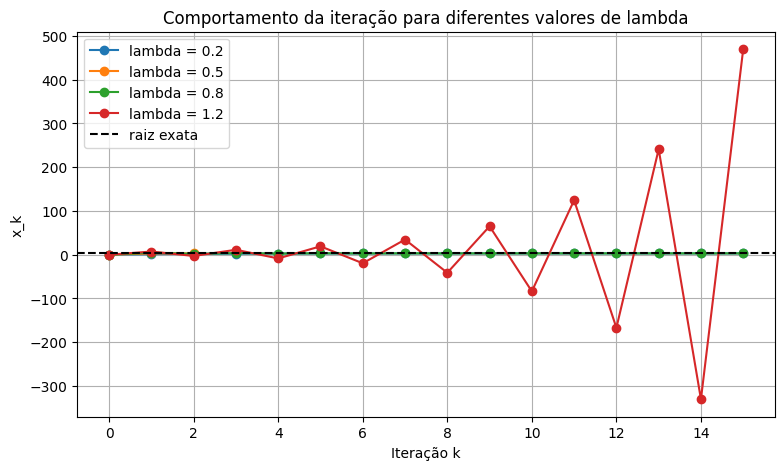

In [16]:
plt.figure(figsize=(9, 5))

valores_lambda = [0.2, 0.5, 0.8, 1.2]

for lamb in valores_lambda:
    historico = iteracao_linear(
        a=2,
        b=-6,
        x0=0,
        lamb=lamb,
        max_iter=15
    )

    plt.plot(
        range(len(historico)),
        historico,
        "o-",
        label=f"lambda = {lamb}"
    )

plt.axhline(3, color="black", linestyle="--", label="raiz exata")
plt.xlabel("Iteração k")
plt.ylabel("x_k")
plt.title("Comportamento da iteração para diferentes valores de lambda")
plt.grid(True)
plt.legend()
plt.show()

## 10.4 Exemplo não linear: encontrar a raiz de `x² - 2`

Agora considere a função:

$$
f(x)=x^2-2
$$

Queremos encontrar o valor de `x` que satisfaz:

$$
x^2-2=0
$$

A raiz positiva desse problema é:

$$
x^*=\sqrt{2}
$$

Para construir uma iteração, escolhemos um valor de `lambda` e usamos:

$$
x_{k+1}=x_k-\lambda f(x_k)
$$

Escolhendo:

$$
\lambda=0{,}3
$$

temos:

$$
x_{k+1}=x_k-0{,}3(x_k^2-2)
$$

Começando com `x_0=1`, calculamos sucessivamente novas aproximações.

Observe que a função original `f(x)=x²-2` é não linear. Porém, a regra de atualização aplica uma correção proporcional ao valor de `f(x_k)`. Por isso, essa abordagem também é chamada de iteração linear ou iteração de primeira ordem.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def iteracao_funcao(f, x0, lamb,
                    tolerancia=1e-10,
                    max_iter=100):
    """
    Aplica a iteração:

        x_(k+1) = x_k - lambda*f(x_k)

    Parâmetros:
        f           função cujo zero será calculado
        x0          estimativa inicial
        lamb        parâmetro de correção
        tolerancia  tolerância para o critério de parada
        max_iter    número máximo de iterações
    """

    x = float(x0)
    historico = [x]

    for k in range(max_iter):
        x_novo = x - lamb*f(x)
        historico.append(x_novo)

        if abs(x_novo - x) < tolerancia:
            break

        x = x_novo

    return historico

Vamos aplicar o método à função:

$$
f(x)=x^2-2
$$

usando:

$$
x_0=1
\qquad\text{e}\qquad
\lambda=0{,}3
$$

A cada iteração, calcularemos:

- a aproximação `x_k`;
- o erro em relação à raiz de referência;
- o resíduo da equação.

O erro exato é calculado apenas para análise, utilizando `numpy.sqrt`. Em um problema real, normalmente não conhecemos a solução exata.

In [18]:
f = lambda x: x**2 - 2

x0 = 1.0
lamb = 0.3

historico = iteracao_funcao(
    f=f,
    x0=x0,
    lamb=lamb,
    tolerancia=1e-10,
    max_iter=100
)

raiz_referencia = np.sqrt(2)

print(" k        x_k              erro absoluto        resíduo")

for k, xk in enumerate(historico):
    erro = abs(xk - raiz_referencia)
    residuo = abs(f(xk))

    print(
        f"{k:2d}   "
        f"{xk:.12f}      "
        f"{erro:.3e}          "
        f"{residuo:.3e}"
    )

 k        x_k              erro absoluto        resíduo
 0   1.000000000000      4.142e-01          1.000e+00
 1   1.300000000000      1.142e-01          3.100e-01
 2   1.393000000000      2.121e-02          5.955e-02
 3   1.410865300000      3.348e-03          9.459e-03
 4   1.413703031577      5.105e-04          1.444e-03
 5   1.414136153130      7.741e-05          2.189e-04
 6   1.414201835253      1.173e-05          3.317e-05
 7   1.414211786003      1.776e-06          5.024e-06
 8   1.414213293302      2.691e-07          7.610e-07
 9   1.414213521616      4.076e-08          1.153e-07
10   1.414213556200      6.173e-09          1.746e-08
11   1.414213561438      9.351e-10          2.645e-09
12   1.414213562231      1.416e-10          4.006e-10
13   1.414213562352      2.146e-11          6.068e-11
14   1.414213562370      3.250e-12          9.192e-12


## 10.5 Como analisar a convergência da iteração

Para avaliar se uma iteração está funcionando, não devemos observar apenas o último valor calculado. É importante analisar toda a sequência:

$$
x_0,\ x_1,\ x_2,\ \ldots,\ x_k
$$

Também devemos acompanhar:

### Erro absoluto

Quando a solução exata é conhecida para fins de comparação:

$$
E_k=|x_k-x^*|
$$

### Resíduo

O resíduo mede quanto a aproximação satisfaz a equação original:

$$
R_k=|f(x_k)|
$$

Para o exemplo `f(x)=x²-2`, temos:

$$
R_k=|x_k^2-2|
$$

### Diferença entre iterações

Podemos verificar a estabilização da sequência usando:

$$
D_k=|x_{k+1}-x_k|
$$

Uma iteração é considerada numericamente estável quando os valores de `D_k` e `R_k` ficam suficientemente pequenos.

Entretanto, uma sequência pode apresentar pequenas diferenças entre iterações e ainda não representar uma solução adequada. Por isso, sempre que possível, devemos verificar também o resíduo.

In [19]:
erros = []
residuos = []
diferencas = []

for k, xk in enumerate(historico):
    erros.append(abs(xk - raiz_referencia))
    residuos.append(abs(f(xk)))

    if k == 0:
        diferencas.append(np.nan)
    else:
        diferencas.append(abs(historico[k] - historico[k-1]))

tabela = pd.DataFrame({
    "iteracao": range(len(historico)),
    "x_k": historico,
    "erro_absoluto": erros,
    "residuo": residuos,
    "diferenca_iteracoes": diferencas
})

display(tabela)

,iteracao,x_k,erro_absoluto,residuo,diferenca_iteracoes
0,0,1.000000,4.142136e-01,1.000000e+00,NaN
1,1,1.300000,1.142136e-01,3.100000e-01,3.000000e-01
2,2,1.393000,2.121356e-02,5.955100e-02,9.300000e-02
3,3,1.410865,3.348262e-03,9.459105e-03,1.786530e-02
4,4,1.413703,5.105308e-04,1.443739e-03,2.837732e-03
5,5,1.414136,7.740924e-05,2.189404e-04,4.331216e-04
6,6,1.414202,1.172712e-05,3.316917e-05,6.568212e-05
7,7,1.414212,1.776370e-06,5.024330e-06,9.950750e-06
8,8,1.414213,2.690710e-07,7.610477e-07,1.507299e-06
9,9,1.414214,4.075671e-08,1.152774e-07,2.283143e-07


## 10.6 Comparação entre valores de `lambda`

O parâmetro `lambda` controla a intensidade da correção:

$$
x_{k+1}=x_k-\lambda f(x_k)
$$

Para a função:

$$
f(x)=x^2-2,
$$

vamos comparar diferentes valores de `lambda`.

Um valor pequeno pode produzir uma convergência lenta. Um valor intermediário pode produzir uma convergência adequada. Um valor muito grande pode provocar oscilações ou divergência.

A escolha de `lambda` deve ser analisada numericamente por meio do histórico de aproximações e dos resíduos.

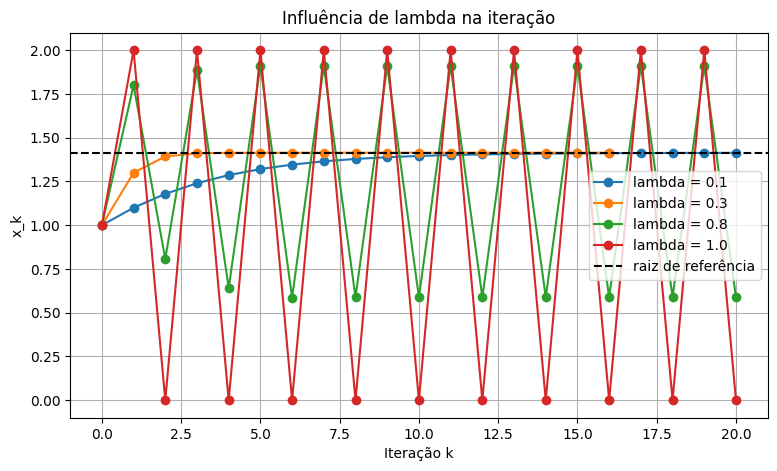

In [20]:
f = lambda x: x**2 - 2
lambdas = [0.1, 0.3, 0.8, 1.0]

plt.figure(figsize=(9, 5))

for lamb in lambdas:
    historico_lamb = iteracao_funcao(
        f=f,
        x0=1.0,
        lamb=lamb,
        tolerancia=1e-12,
        max_iter=20
    )

    plt.plot(
        range(len(historico_lamb)),
        historico_lamb,
        "o-",
        label=f"lambda = {lamb}"
    )

plt.axhline(
    np.sqrt(2),
    color="black",
    linestyle="--",
    label="raiz de referência"
)

plt.xlabel("Iteração k")
plt.ylabel("x_k")
plt.title("Influência de lambda na iteração")
plt.grid(True)
plt.legend()
plt.show()

## 10.7 Exemplos de iterações que não convergem

Nem toda função iterativa produz uma sequência convergente.

Considere primeiro:

$$
g(x)=2x
$$

O ponto fixo dessa função é `x*=0`, pois:

$$
g(0)=0
$$

Entretanto, começando com `x_0=1`, temos:

$$
x_1=2,
\qquad
x_2=4,
\qquad
x_3=8,
\qquad
x_4=16
$$

O módulo dos valores aumenta. A sequência diverge.

Agora considere:

$$
g(x)=-x
$$

Começando com `x_0=1`, obtemos:

$$
x_1=-1,
\qquad
x_2=1,
\qquad
x_3=-1
$$

A sequência oscila continuamente e não se aproxima de um único valor.

Esses exemplos mostram que possuir um ponto fixo não é suficiente. Também é necessário que a função iterativa reduza os erros próximos do ponto fixo.

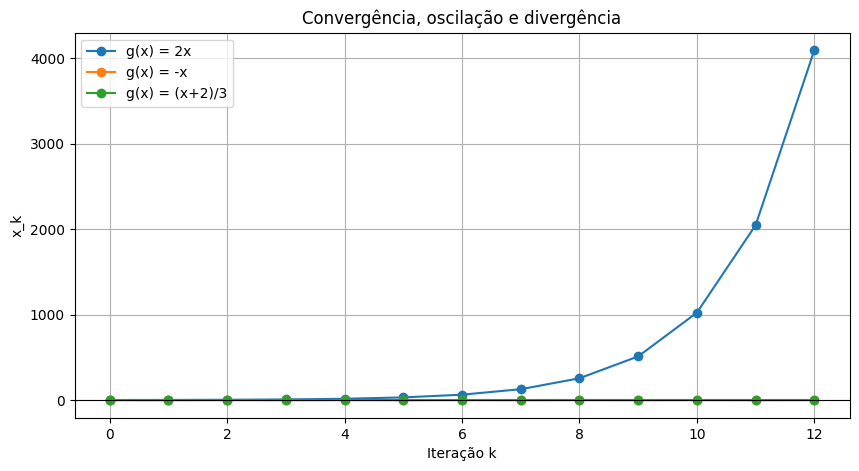

In [21]:
def iterar_com_historico(g, x0, max_iter=15):
    historico = [float(x0)]
    x = float(x0)

    for _ in range(max_iter):
        x = float(g(x))
        historico.append(x)

    return historico


casos = [
    (lambda x: 2*x, "g(x) = 2x"),
    (lambda x: -x, "g(x) = -x"),
    (lambda x: (x+2)/3, "g(x) = (x+2)/3")
]

plt.figure(figsize=(10, 5))

for g, nome in casos:
    historico_g = iterar_com_historico(g, x0=1, max_iter=12)

    plt.plot(
        range(len(historico_g)),
        historico_g,
        "o-",
        label=nome
    )

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Iteração k")
plt.ylabel("x_k")
plt.title("Convergência, oscilação e divergência")
plt.grid(True)
plt.legend()
plt.show()

### Interpretação dos resultados

- Para `g(x)=2x`, os valores se afastam do ponto fixo. A sequência diverge.
- Para `g(x)=-x`, os valores alternam entre dois números. A sequência oscila.
- Para `g(x)=(x+2)/3`, a amplitude diminui e a sequência converge para `x*=1`.

A condição associada a esse comportamento é:

$$
|g'(x^*)|<1
$$

Quando essa condição é satisfeita em uma região próxima ao ponto fixo, pequenos erros tendem a ser reduzidos. Quando:

$$
|g'(x^*)|>1,
$$

os erros tendem a aumentar.

Portanto, antes de utilizar um método iterativo, devemos analisar:

- a função iterativa escolhida;
- a estimativa inicial;
- a derivada ou inclinação local;
- o comportamento do erro;
- o resíduo da equação;
- o número máximo de iterações.

## 12. Atividade prática final

1. Calcule `sqrt(37)` com `x0=6`.
2. Monte uma tabela com `k`, `x_k`, erro entre iterações e resíduo.
3. Repita com tolerâncias `10⁻4`, `10⁻8` e `10⁻12`.
4. Teste as iterações lineares para `f(x)=2x-6` usando `lambda=0.2`, `0.5` e `1.2`.
5. Produza gráficos para `g(x)=2x`, `g(x)=-x` e `g(x)=(x+2)/3`.
6. Explique por que os dois primeiros casos não convergem.
7. Calcule a diagonal de um quadrado de lado `2,75 m` e a norma do vetor `(1.2,-3.4,5.6)`.
8. Compare erro entre iterações e resíduo como critérios de parada.

## Síntese

O método babilônico usa a regra:

$$x_{k+1}=\frac{1}{2}\left(x_k+\frac{S}{x_k}\right).$$

Ele é uma iteração de ponto fixo simples, rápida e útil em diversas aplicações. Uma solução numérica confiável exige acompanhar a convergência, escolher uma tolerância coerente, verificar o resíduo e reconhecer situações de divergência.